> ## Роль в pipeline
>
> **Назначение:** **production-кандидат** для весов фичей Health Score.
>
> **Что делает:** unsupervised consensus index — **никакого внешнего таргета**. Каждая фича сама себе ground truth + ручной флаг направления (`+1` / `−1`). Веса подбираются так, чтобы score максимально коррелировал **со всеми** ориентированными фичами одновременно.
>
> **Методы:**
> - **Equal** (baseline 1/k)
> - **PC1** — первая главная компонента (натуральные веса по силе общего фактора)
> - **OptMean** — максимум средней корреляции (= equal на стандартизованных X)
> - **OptMin** — максимум минимальной корреляции (никто не игнорируется, но средняя ниже)
>
> **Использование:** **источник финальных весов** Health Score. PC1 loadings или OptMin → передаются в `compute_health_score(weights=...)` в финальном фреймворке (или конфиг `src/metric/config.yaml`).
>
> **Ключевой результат:** PC1 объясняет ~42% дисперсии — общий health-фактор существует. `cart_rate` (loading 0.22) и `km_median_time_to_cart_s` (loading 0.08) слабо вписываются → отдельные индикаторы, не агрегировать.
>
> **Статус:** **active**, кандидат на финальные веса. После выбора варианта (PC1 vs OptMin) импортировать веса в `new_metric.ipynb` / framework config.


# Health Score: Consensus Index

Идея: **никакого внешнего таргета**. Только курируемый набор фичей, для каждой задаём направление «хорошо» (↑ или ↓). Веса подбираются так, чтобы итоговый score максимально коррелировал **сразу со всеми** ориентированными фичами.

Это uniformly unsupervised: score = «общий фактор здоровья», вытащенный из ансамбля сигналов.

## Подходы

| # | Метод | Что максимизирует |
|---|---|---|
| 1 | **Equal weights** | baseline (1/k каждой) |
| 2 | **PC1** | первая главная компонента стандартизованных ориентированных фичей — explains max common variance |
| 3 | **Optim** | численная оптимизация min/mean corr(score, xᵢ) под симплекс w≥0, Σw=1 |

## Если фичи не согласованы

Если в матрице корреляций ориентированных фичей есть отрицательные ячейки — значит часть «↑=хорошо» сигналов на самом деле движется против остальных. Тогда:
- либо ошиблись в направлении,
- либо это разные оси качества (нельзя в один скор).

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
DATA_DIR = Path('../../data/daily_summaries')
print('OK')

OK


## 1. Курируемый набор фичей и направления

`+1` = «больше = лучше», `-1` = «больше = хуже».
Для `-1` фичей берём `−x` (или `1−x` для долей) при ориентации.

| Фича | Dir | Почему |
|---|---|---|
| `cart_rate` | +1 | Среднее # добавлений в корзину на сессию (event-based) — главный коммерческий сигнал |
| `rate_clicks` | +1 | Engagement |
| `rate_views` | +1 | Просмотры товаров |
| `rate_unique_queries` | +1 | Разнообразие интересов |
| `multi_category_rate` | +1 | Кросс-категорийный exploration |
| `mean_duration_s` | +1 | Время на сайте (engagement; для shopping NB нормально что больше=лучше) |
| `search_refinement_rate` | +1 | Уточнение запроса = engaged user (corr +0.60 с cart_rate, не фрустрация) |
| `dead_search_rate` | −1 | Поиск без клика — фрустрация |
| `bounce_rate` | −1 | Сессия из 1 события |
| `km_median_time_to_cart_s` | −1 | Быстрее до корзины = лучше движок |

10 фичей. Включаем `km_speed_to_cart` сознательно — если он анти-коррелирует с conversion-сигналами после ориентации, PC1 это покажет.

In [2]:
df_cat = pl.read_parquet(str(DATA_DIR / '*.parquet'))

FEATURES_DIR = {
    'cart_rate':                +1,
    'rate_clicks':              +1,
    'rate_views':               +1,
    'rate_unique_queries':      +1,
    'multi_category_rate':      +1,
    'mean_duration_s':          +1,
    'search_refinement_rate':   +1,
    'dead_search_rate':         -1,
    'bounce_rate':              -1,
    'km_median_time_to_cart_s': -1,
}
FEATURES = list(FEATURES_DIR.keys())
DIRS = np.array([FEATURES_DIR[f] for f in FEATURES])

# Aggregate to daily (null-aware weighted mean)
weighted_aggs = [(pl.col(c) * pl.col('n_sessions')).sum().alias(f'_w_{c}') for c in FEATURES]
denom_aggs = [
    pl.when(pl.col(c).is_not_null()).then(pl.col('n_sessions'))
      .otherwise(pl.lit(0, dtype=pl.UInt32)).sum().alias(f'_d_{c}')
    for c in FEATURES
]
daily = (
    df_cat.group_by('date').agg([
        pl.col('n_sessions').sum().alias('n_sessions'),
        pl.col('is_cart').sum().alias('is_cart'),
        *weighted_aggs, *denom_aggs,
    ]).with_columns([
        pl.when(pl.col(f'_d_{c}') > 0).then(pl.col(f'_w_{c}') / pl.col(f'_d_{c}'))
          .otherwise(None).alias(c)
        for c in FEATURES
    ]).drop([f'_w_{c}' for c in FEATURES] + [f'_d_{c}' for c in FEATURES])
      .sort('date')
).to_pandas()
daily['date'] = pd.to_datetime(daily['date'])

# Orient: умножаем на dir, потом стандартизуем. После этого «больше = лучше» для всех.
X_raw = daily[FEATURES].values
X_oriented_raw = X_raw * DIRS  # +x или -x
scaler = StandardScaler().fit(X_oriented_raw)
X = scaler.transform(X_oriented_raw)  # z-нормализованные ориентированные фичи

X_df = pd.DataFrame(X, columns=FEATURES, index=daily['date'])
print(f'Дней: {len(daily)}, фичей: {len(FEATURES)}')
print(f'NaN: {X_df.isna().sum().sum()}')
X_df.describe().round(3)

Дней: 61, фичей: 10
NaN: 0


,cart_rate,rate_clicks,rate_views,rate_unique_queries,multi_category_rate,mean_duration_s,search_refinement_rate,dead_search_rate,bounce_rate,km_median_time_to_cart_s
count,61.000,61.000,61.000,61.000,61.000,61.000,61.000,61.000,61.000,61.000
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000
std,1.008,1.008,1.008,1.008,1.008,1.008,1.008,1.008,1.008,1.008
min,-2.914,-1.776,-1.616,-1.234,-6.521,-1.777,-2.767,-4.572,-5.622,-7.288
25%,-0.289,-0.674,-0.560,-0.643,-0.198,-0.557,-0.393,-0.425,-0.380,-0.033
50%,0.101,-0.218,-0.308,-0.278,0.058,-0.048,0.067,0.053,-0.045,0.167
75%,0.550,0.222,-0.014,0.128,0.339,0.562,0.484,0.488,0.510,0.363
max,3.026,2.676,2.972,2.950,1.633,3.203,3.335,2.519,1.545,1.051


## 2. Sanity check: матрица корреляций ориентированных фичей

Если направления заданы правильно — большинство ячеек должно быть **положительным** (все фичи `↑=хорошо` со-движутся). Отрицательные ячейки = либо ошибка направления, либо разные оси качества.

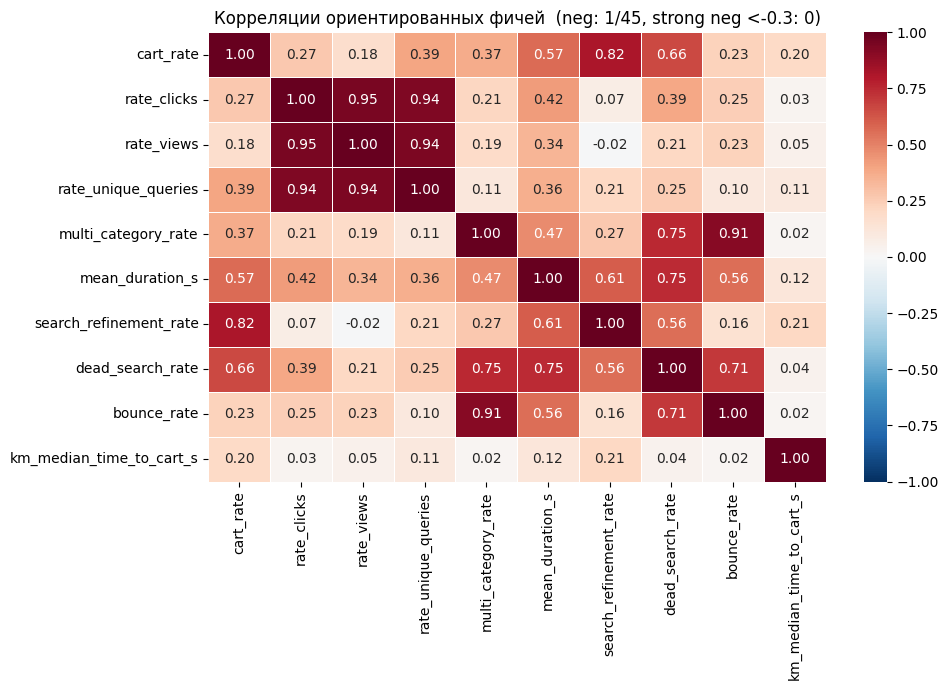

Доля отрицательных пар: 1/45 (2%)
Сильно отрицательных (<-0.3): 0


In [3]:
corr_matrix = X_df.corr()
n_total = len(FEATURES) * (len(FEATURES) - 1) // 2
upper = corr_matrix.values[np.triu_indices_from(corr_matrix, k=1)]
n_neg = (upper < 0).sum()
n_strong_neg = (upper < -0.3).sum()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title(f'Корреляции ориентированных фичей  '
             f'(neg: {n_neg}/{n_total}, strong neg <-0.3: {n_strong_neg})')
plt.tight_layout()
plt.show()

print(f'Доля отрицательных пар: {n_neg}/{n_total} ({100*n_neg/n_total:.0f}%)')
print(f'Сильно отрицательных (<-0.3): {n_strong_neg}')
if n_strong_neg > 0:
    print('\n⚠️ Сильные отрицательные пары:')
    for i, f1 in enumerate(FEATURES):
        for j, f2 in enumerate(FEATURES):
            if i < j and corr_matrix.loc[f1, f2] < -0.3:
                print(f'  {f1:30s} ↔ {f2:30s}  r = {corr_matrix.loc[f1, f2]:+.2f}')

## 3. Подход 1 — Equal weights (baseline)

`w = (1/k, …, 1/k)`. Score = простое среднее z-нормализованных ориентированных фичей.

In [4]:
def score_corrs(weights, X, feature_names):
    """Возвращает Series corr(score, x_i) для каждой фичи."""
    s = X @ weights
    return pd.Series([np.corrcoef(s, X[:, i])[0, 1] for i in range(X.shape[1])],
                     index=feature_names)

w_equal = pd.Series(np.ones(len(FEATURES)) / len(FEATURES), index=FEATURES)
corrs_equal = score_corrs(w_equal.values, X, FEATURES)

print(f'Equal weights mean corr = {corrs_equal.mean():.3f}, min = {corrs_equal.min():.3f}')
print('\nКорр score с каждой фичей:')
print(corrs_equal.sort_values(ascending=False).round(3))

Equal weights mean corr = 0.651, min = 0.275

Корр score с каждой фичей:
dead_search_rate            0.818
mean_duration_s             0.799
cart_rate                   0.720
rate_clicks                 0.697
rate_unique_queries         0.677
multi_category_rate         0.663
bounce_rate                 0.639
rate_views                  0.625
search_refinement_rate      0.596
km_median_time_to_cart_s    0.275
dtype: float64


## 4. Подход 2 — PC1 (eigenvector корреляционной матрицы)

Первая главная компонента максимизирует **долю общей дисперсии**, объяснённой одним направлением. Для consensus-индекса это золотой стандарт.

Если все loadings положительные — все фичи реально вкладываются в общий «health»-фактор. Если у кого-то отрицательный loading — он движется против общего направления (ошибка в `dir` или фича из другой оси).

In [6]:
eigvals, eigvecs = np.linalg.eigh(corr_matrix.values)
# eigh даёт по возрастанию — берём последний
pc1 = eigvecs[:, -1]
pc1_var = eigvals[-1] / eigvals.sum()

# Знак: PC1 определена с точностью до знака. Выравниваем чтобы сумма loadings была положительной.
if pc1.sum() < 0:
    pc1 = -pc1

pc1_loadings = pd.Series(pc1, index=FEATURES)
print(f'PC1 explained variance: {pc1_var*100:.1f}%')
print(f'\nPC1 loadings (знак показывает: положительный = вкладывается в общий health-фактор):')
print(pc1_loadings.sort_values(ascending=False).round(3))

n_neg_loadings = (pc1_loadings < 0).sum()
if n_neg_loadings > 0:
    print(f'\n⚠️ {n_neg_loadings} фичей с отрицательным loading — они движутся ПРОТИВ общего фактора')
    print('   Кандидаты на исключение или пересмотр direction:')
    for f, v in pc1_loadings.items():
        if v < 0:
            print(f'   {f}: {v:+.3f}')

w_pc1 = pc1_loadings.abs() / pc1_loadings.abs().sum()
corrs_pc1 = score_corrs(w_pc1.values * np.sign(pc1_loadings.values), X, FEATURES)
print(f'\nPC1 веса (|loading| нормированные):')
print(w_pc1.sort_values(ascending=False).round(3))
print(f'\nPC1 mean corr = {corrs_pc1.mean():.3f}, min = {corrs_pc1.min():.3f}')

PC1 explained variance: 45.0%

PC1 loadings (знак показывает: положительный = вкладывается в общий health-фактор):
dead_search_rate            0.402
mean_duration_s             0.386
cart_rate                   0.338
rate_clicks                 0.329
multi_category_rate         0.324
bounce_rate                 0.314
rate_unique_queries         0.311
rate_views                  0.290
search_refinement_rate      0.278
km_median_time_to_cart_s    0.074
dtype: float64

PC1 веса (|loading| нормированные):
dead_search_rate            0.132
mean_duration_s             0.127
cart_rate                   0.111
rate_clicks                 0.108
multi_category_rate         0.107
bounce_rate                 0.103
rate_unique_queries         0.102
rate_views                  0.095
search_refinement_rate      0.091
km_median_time_to_cart_s    0.024
dtype: float64

PC1 mean corr = 0.646, min = 0.156


## 5. Подход 3 — Численная оптимизация

Максимизируем **средний** или **минимальный** corr(Xw, xᵢ) под ограничением: `wᵢ ≥ 0, Σ wᵢ = 1` (симплекс).

Две функции потерь:
- `mean_corr` — общая согласованность (доминирующие фичи могут «съесть» одиночек)
- `min_corr` — гарантия что **ни одна** фича не отбрасывается (max-min справедливость)

In [7]:
def neg_mean_corr(w, X):
    s = X @ w
    s_std = s.std()
    if s_std < 1e-12:
        return 0.0
    # X уже z-нормализован → cov(s, x_i) = mean(s * x_i), corr = cov / s_std
    corrs = (X.T @ s) / (X.shape[0] * s_std)
    return -corrs.mean()

def neg_min_corr(w, X):
    s = X @ w
    s_std = s.std()
    if s_std < 1e-12:
        return 0.0
    corrs = (X.T @ s) / (X.shape[0] * s_std)
    return -corrs.min()

k = len(FEATURES)
w0 = np.ones(k) / k
bounds = [(0, 1)] * k
constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]

opt_mean = minimize(neg_mean_corr, w0, args=(X,), method='SLSQP',
                    bounds=bounds, constraints=constraints,
                    options={'maxiter': 500, 'ftol': 1e-9})
opt_min = minimize(neg_min_corr, w0, args=(X,), method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'maxiter': 500, 'ftol': 1e-9})

w_opt_mean = pd.Series(opt_mean.x, index=FEATURES)
w_opt_min = pd.Series(opt_min.x, index=FEATURES)

corrs_opt_mean = score_corrs(w_opt_mean.values, X, FEATURES)
corrs_opt_min = score_corrs(w_opt_min.values, X, FEATURES)

print(f'Optim (max mean corr): mean={corrs_opt_mean.mean():.3f}, min={corrs_opt_mean.min():.3f}')
print(w_opt_mean.sort_values(ascending=False).round(3))
print(f'\nOptim (max min corr):  mean={corrs_opt_min.mean():.3f}, min={corrs_opt_min.min():.3f}')
print(w_opt_min.sort_values(ascending=False).round(3))

Optim (max mean corr): mean=0.651, min=0.275
cart_rate                   0.1
rate_clicks                 0.1
rate_views                  0.1
rate_unique_queries         0.1
multi_category_rate         0.1
mean_duration_s             0.1
search_refinement_rate      0.1
dead_search_rate            0.1
bounce_rate                 0.1
km_median_time_to_cart_s    0.1
dtype: float64

Optim (max min corr):  mean=0.601, min=0.574
rate_views                  0.269
km_median_time_to_cart_s    0.262
search_refinement_rate      0.243
bounce_rate                 0.221
multi_category_rate         0.005
mean_duration_s             0.000
rate_unique_queries         0.000
cart_rate                   0.000
rate_clicks                 0.000
dead_search_rate            0.000
dtype: float64


## 6. Сравнение

In [8]:
weights_table = pd.DataFrame({
    'Equal':     w_equal,
    'PC1':       w_pc1,
    'OptMean':   w_opt_mean,
    'OptMin':    w_opt_min,
}).round(3)

corrs_table = pd.DataFrame({
    'Equal':     corrs_equal,
    'PC1':       corrs_pc1,
    'OptMean':   corrs_opt_mean,
    'OptMin':    corrs_opt_min,
}).round(3)

summary = pd.DataFrame({
    'mean_corr': [corrs_equal.mean(), corrs_pc1.mean(),
                  corrs_opt_mean.mean(), corrs_opt_min.mean()],
    'min_corr':  [corrs_equal.min(),  corrs_pc1.min(),
                  corrs_opt_mean.min(),  corrs_opt_min.min()],
}, index=['Equal', 'PC1', 'OptMean', 'OptMin']).round(3)

print('=== Веса ===')
print(weights_table.sort_values('PC1', ascending=False))
print('\n=== Корреляция score с каждой фичей ===')
print(corrs_table.sort_values('PC1', ascending=False))
print('\n=== Сводная ===')
print(summary)

=== Веса ===
                          Equal    PC1  OptMean  OptMin
dead_search_rate            0.1  0.132      0.1   0.000
mean_duration_s             0.1  0.127      0.1   0.000
cart_rate                   0.1  0.111      0.1   0.000
rate_clicks                 0.1  0.108      0.1   0.000
multi_category_rate         0.1  0.107      0.1   0.005
bounce_rate                 0.1  0.103      0.1   0.221
rate_unique_queries         0.1  0.102      0.1   0.000
rate_views                  0.1  0.095      0.1   0.269
search_refinement_rate      0.1  0.091      0.1   0.243
km_median_time_to_cart_s    0.1  0.024      0.1   0.262

=== Корреляция score с каждой фичей ===
                          Equal    PC1  OptMean  OptMin
dead_search_rate          0.818  0.853    0.818   0.633
mean_duration_s           0.799  0.818    0.799   0.692
cart_rate                 0.720  0.717    0.720   0.610
rate_clicks               0.697  0.697    0.697   0.587
multi_category_rate       0.663  0.688    0.663   

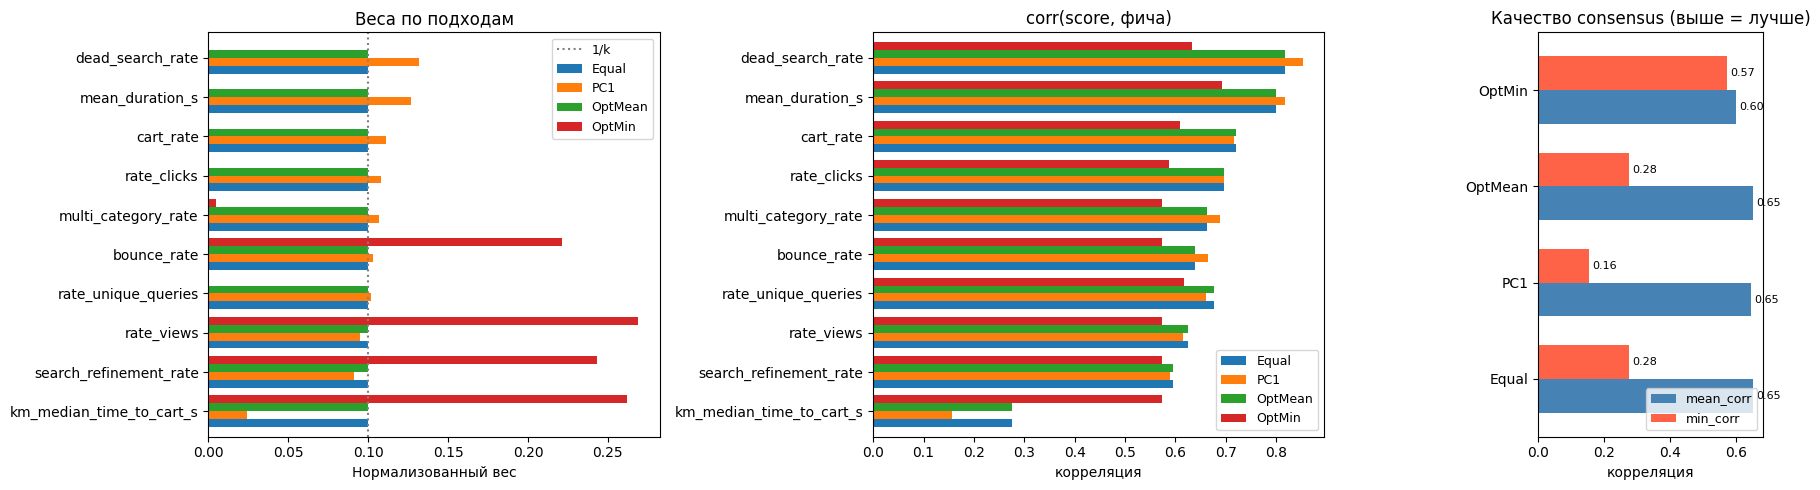

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         gridspec_kw={'width_ratios': [1, 1, 0.5]})

# Веса
weights_table.sort_values('PC1', ascending=True).plot.barh(ax=axes[0], width=0.8)
axes[0].set_title('Веса по подходам')
axes[0].set_xlabel('Нормализованный вес')
axes[0].axvline(1/len(FEATURES), color='gray', linestyle=':', label='1/k')
axes[0].legend(fontsize=9)

# Корреляции score с каждой фичей
corrs_table.sort_values('PC1', ascending=True).plot.barh(ax=axes[1], width=0.8)
axes[1].set_title('corr(score, фича)')
axes[1].set_xlabel('корреляция')
axes[1].axvline(0, color='black', lw=0.5)
axes[1].legend(fontsize=9)

# Сводка: mean_corr и min_corr per метод
summary_plot = summary[['mean_corr', 'min_corr']]
summary_plot.plot.barh(ax=axes[2], width=0.7,
                       color=['steelblue', 'tomato'])
axes[2].set_title('Качество consensus (выше = лучше)')
axes[2].set_xlabel('корреляция')
axes[2].axvline(0, color='black', lw=0.5)
axes[2].legend(fontsize=9, loc='lower right')
# Аннотации значений
for i, (idx, row) in enumerate(summary_plot.iterrows()):
    for j, val in enumerate(row.values):
        axes[2].text(val + 0.01 if val >= 0 else val - 0.01,
                     i + (j - 0.5) * 0.35, f'{val:.2f}',
                     va='center', fontsize=8,
                     ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.show()

## 7. Score во времени

Как выглядит выбранный consensus score за период.

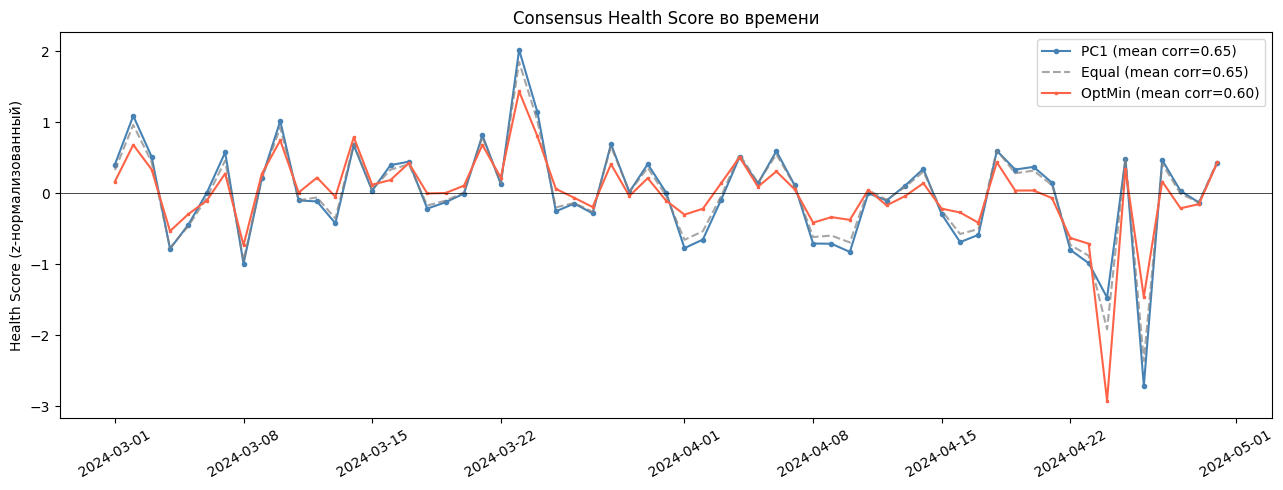

PC1 score:  min=-2.71, max=2.02, самый плохой день: 2024-04-26
           самый хороший день: 2024-03-23


In [10]:
score_pc1 = X @ (w_pc1.values * np.sign(pc1_loadings.values))
score_eq = X @ w_equal.values
score_min = X @ w_opt_min.values

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily['date'], score_pc1, label=f'PC1 (mean corr={corrs_pc1.mean():.2f})',
        color='steelblue', marker='o', markersize=3)
ax.plot(daily['date'], score_eq, label=f'Equal (mean corr={corrs_equal.mean():.2f})',
        color='gray', linestyle='--', alpha=0.7)
ax.plot(daily['date'], score_min, label=f'OptMin (mean corr={corrs_opt_min.mean():.2f})',
        color='tomato', marker='s', markersize=2)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Health Score (z-нормализованный)')
ax.set_title('Consensus Health Score во времени')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f'PC1 score:  min={score_pc1.min():.2f}, max={score_pc1.max():.2f}, '
      f'самый плохой день: {daily.loc[score_pc1.argmin(), "date"].date()}')
print(f'           самый хороший день: {daily.loc[score_pc1.argmax(), "date"].date()}')

## 8. Выводы

**Что показал PC1:**
- Доля объяснённой дисперсии PC1 — насколько вообще существует «общий health-фактор» в этом наборе фичей.
- Положительные loadings = фичи в фактор вкладываются. Отрицательные = фича противоречит остальным (ошибка в `dir` или другая ось).

**Что показал Optim:**
- `OptMean` максимизирует среднюю корреляцию — может «утопить» одну фичу ради остальных.
- `OptMin` гарантирует что ни одна фича не игнорируется.

**Читать таблицу:**
- Маленький вес у фичи в `OptMean` + маленькая `corr(score, x_i)` → фича ортогональна остальным, не вписалась в consensus.
- Маленький вес у фичи в `OptMin` + corr заметная → фича уже хорошо отслеживается через корреляцию с другими (избыточна).

**Что делать дальше:**
1. Если фичи с отрицательным PC1-loading появились — пересмотреть `FEATURES_DIR` или убрать их из набора.
2. Сравнить score с экспертной оценкой «хороший/плохой день» (если есть лог инцидентов).
3. Если экспертный лог отсутствует — `OptMin` или `PC1` дают разумный default.